# 🩺 EDA — Diabetes Health Indicators (BRFSS 2015)

```
project/
├── data/
│   ├── raw/         diabetes_binary_5050split_health_indicators_BRFSS2015.csv
│   └── processed/   train.csv · test.csv
├── notebooks/       eda.ipynb  
├── src/             preprocessing.py
└── reports/         sprint1_report.md
```

**Cible :** `Diabetes_binary` — 0 = non-diabétique · 1 = diabétique/pré-diabétique  
**Dataset :** CDC BRFSS 2015 · 50/50 split · 70 692 observations brutes

---
## 📋 Sommaire
1. [Setup & imports](#1-setup)
2. [Lancer le preprocessing](#2-preprocessing)
3. [Aperçu des données](#3-apercu)
4. [Distribution de la cible](#4-cible)
5. [Distributions par feature](#5-features)
6. [Heatmap de corrélations](#6-correlations)
7. [Feature Importance — Random Forest](#7-importance)
8. [Conclusions & prochaines étapes](#8-conclusions)


## 1. Setup & imports <a id='1-setup'></a>

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

PALETTE = ['#4C72B0', '#DD8452']
BG, ACCENT, ACCENT2, DARK = '#F8F9FA', '#4C72B0', '#DD8452', '#1a1a2e'
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.facecolor': BG, 'axes.facecolor': BG,
                     'axes.edgecolor': '#cccccc', 'axes.titleweight': 'bold'})
print('✅ Imports OK — PROJECT_ROOT:', PROJECT_ROOT)


✅ Imports OK — PROJECT_ROOT: /Users/enzofraioli/Documents/Académique/CESI/FISE A4/2-Deep_Learning/Projet/BigData


## 2. Lancer le preprocessing <a id='2-preprocessing'></a>
Génère `data/processed/train.csv` et `test.csv` via `src/preprocessing.py`.  
*Si les fichiers existent déjà, chargement direct.*


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# Vérifie quel fichier Python charge
import preprocessing
print(preprocessing.__file__)

# Liste les fonctions disponibles
import inspect
funcs = [f for f, _ in inspect.getmembers(preprocessing, inspect.isfunction)]
print("Fonctions disponibles :", funcs)

/Users/enzofraioli/Documents/Académique/CESI/FISE A4/2-Deep_Learning/Projet/BigData/src/preprocessing.py
Fonctions disponibles : ['engineer_features', 'load_data', 'run_pipeline', 'save', 'scale_continuous', 'split_data', 'train_test_split', 'validate']


In [3]:
from preprocessing import run_pipeline

TRAIN_PATH = PROJECT_ROOT / 'data' / 'processed' / 'train.csv'
TEST_PATH  = PROJECT_ROOT / 'data' / 'processed' / 'test.csv'
TARGET     = 'Diabetes_binary'

if not TRAIN_PATH.exists() or not TEST_PATH.exists():
    train_df, test_df = run_pipeline(scale=True)
else:
    train_df = pd.read_csv(TRAIN_PATH)
    test_df  = pd.read_csv(TEST_PATH)
    print(f'✅ Fichiers processed chargés. Train: {train_df.shape} | Test: {test_df.shape}')

raw_df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
print(f'Dataset brut : {raw_df.shape}')


✅ Fichiers processed chargés. Train: (55245, 26) | Test: (13812, 26)
Dataset brut : (70692, 22)


## 3. Aperçu des données <a id='3-apercu'></a>

In [4]:
BINARY_FEATURES = [
    'HighBP','HighChol','CholCheck','Smoker','Stroke','HeartDiseaseorAttack',
    'PhysActivity','Fruits','Veggies','HvyAlcoholConsump','AnyHealthcare',
    'NoDocbcCost','DiffWalk','Sex',
]
ORDINAL_FEATURES   = ['GenHlth','Age','Education','Income']
CONTINUOUS_FEATURES = ['BMI','MentHlth','PhysHlth']
ENGINEERED         = ['Obese','CardioRisk','UnhealthyLifestyle','PoorHealth']

print(f'Shape brut      : {raw_df.shape}')
print(f'Shape train     : {train_df.shape}')
print(f'Doublons brut   : {raw_df.duplicated().sum()}')
print(f'Valeurs manq.   : {raw_df.isnull().sum().sum()}')
raw_df.head(3)


Shape brut      : (70692, 22)
Shape train     : (55245, 26)
Doublons brut   : 1635
Valeurs manq.   : 0


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0


In [5]:
raw_df[CONTINUOUS_FEATURES + ORDINAL_FEATURES].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
BMI,70692.0,29.86,7.11,12.0,25.0,29.0,33.0,98.0
MentHlth,70692.0,3.75,8.16,0.0,0.0,0.0,2.0,30.0
PhysHlth,70692.0,5.81,10.06,0.0,0.0,0.0,6.0,30.0
GenHlth,70692.0,2.84,1.11,1.0,2.0,3.0,4.0,5.0
Age,70692.0,8.58,2.85,1.0,7.0,9.0,11.0,13.0
Education,70692.0,4.92,1.03,1.0,4.0,5.0,6.0,6.0
Income,70692.0,5.70,2.18,1.0,4.0,6.0,8.0,8.0


In [6]:
# Résumé des types de variables
summary = pd.DataFrame([
    {'Type': 'Binaire',    'Count': len(BINARY_FEATURES),    'Features': ', '.join(BINARY_FEATURES)},
    {'Type': 'Ordinale',   'Count': len(ORDINAL_FEATURES),   'Features': ', '.join(ORDINAL_FEATURES)},
    {'Type': 'Continue',   'Count': len(CONTINUOUS_FEATURES),'Features': ', '.join(CONTINUOUS_FEATURES)},
    {'Type': 'Engineered', 'Count': len(ENGINEERED),         'Features': ', '.join(ENGINEERED)},
])
summary


,Type,Count,Features
0,Binaire,14,"HighBP, HighChol, CholCheck, Smoker, Stroke, H..."
1,Ordinale,4,"GenHlth, Age, Education, Income"
2,Continue,3,"BMI, MentHlth, PhysHlth"
3,Engineered,4,"Obese, CardioRisk, UnhealthyLifestyle, PoorHealth"


## 4. Distribution de la cible <a id='4-cible'></a>

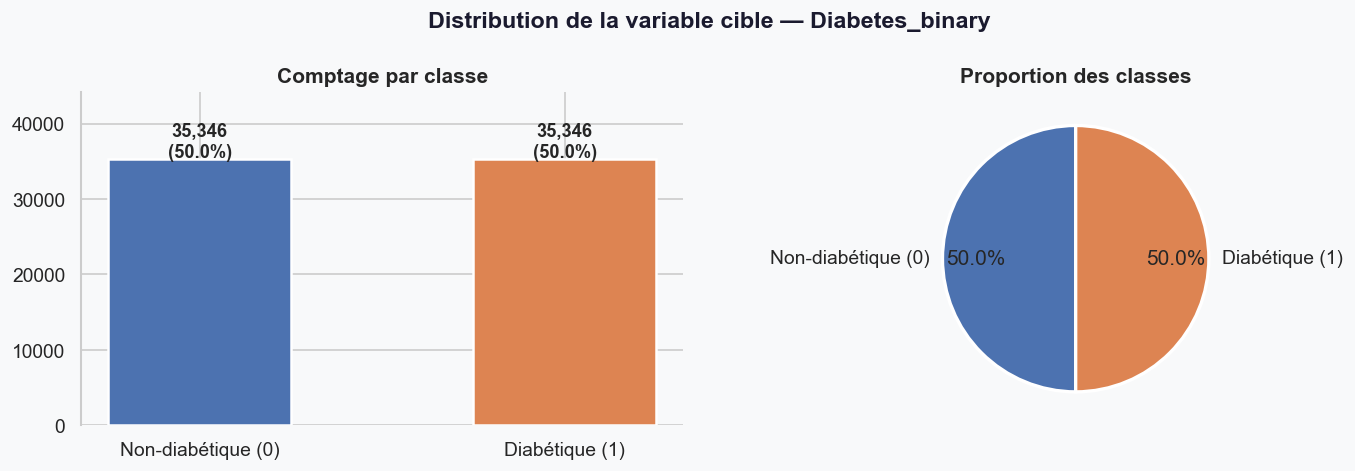

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=BG)
fig.suptitle('Distribution de la variable cible — Diabetes_binary', fontsize=14, fontweight='bold', color=DARK)
counts = raw_df[TARGET].value_counts().sort_index()
labels = ['Non-diabétique (0)', 'Diabétique (1)']

bars = axes[0].bar(labels, counts.values, color=PALETTE, width=0.5, edgecolor='white', linewidth=1.5)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+200,
                 f'{v:,}\n({v/len(raw_df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Comptage par classe')
axes[0].set_ylim(0, counts.max()*1.25)
sns.despine(ax=axes[0], bottom=True)

axes[1].pie(counts.values, labels=labels, colors=PALETTE, autopct='%1.1f%%',
            startangle=90, pctdistance=0.75, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proportion des classes')
plt.tight_layout(); plt.show()


## 5. Distributions par feature <a id='5-features'></a>

### 5.1 Variables binaires — taux de prévalence par classe

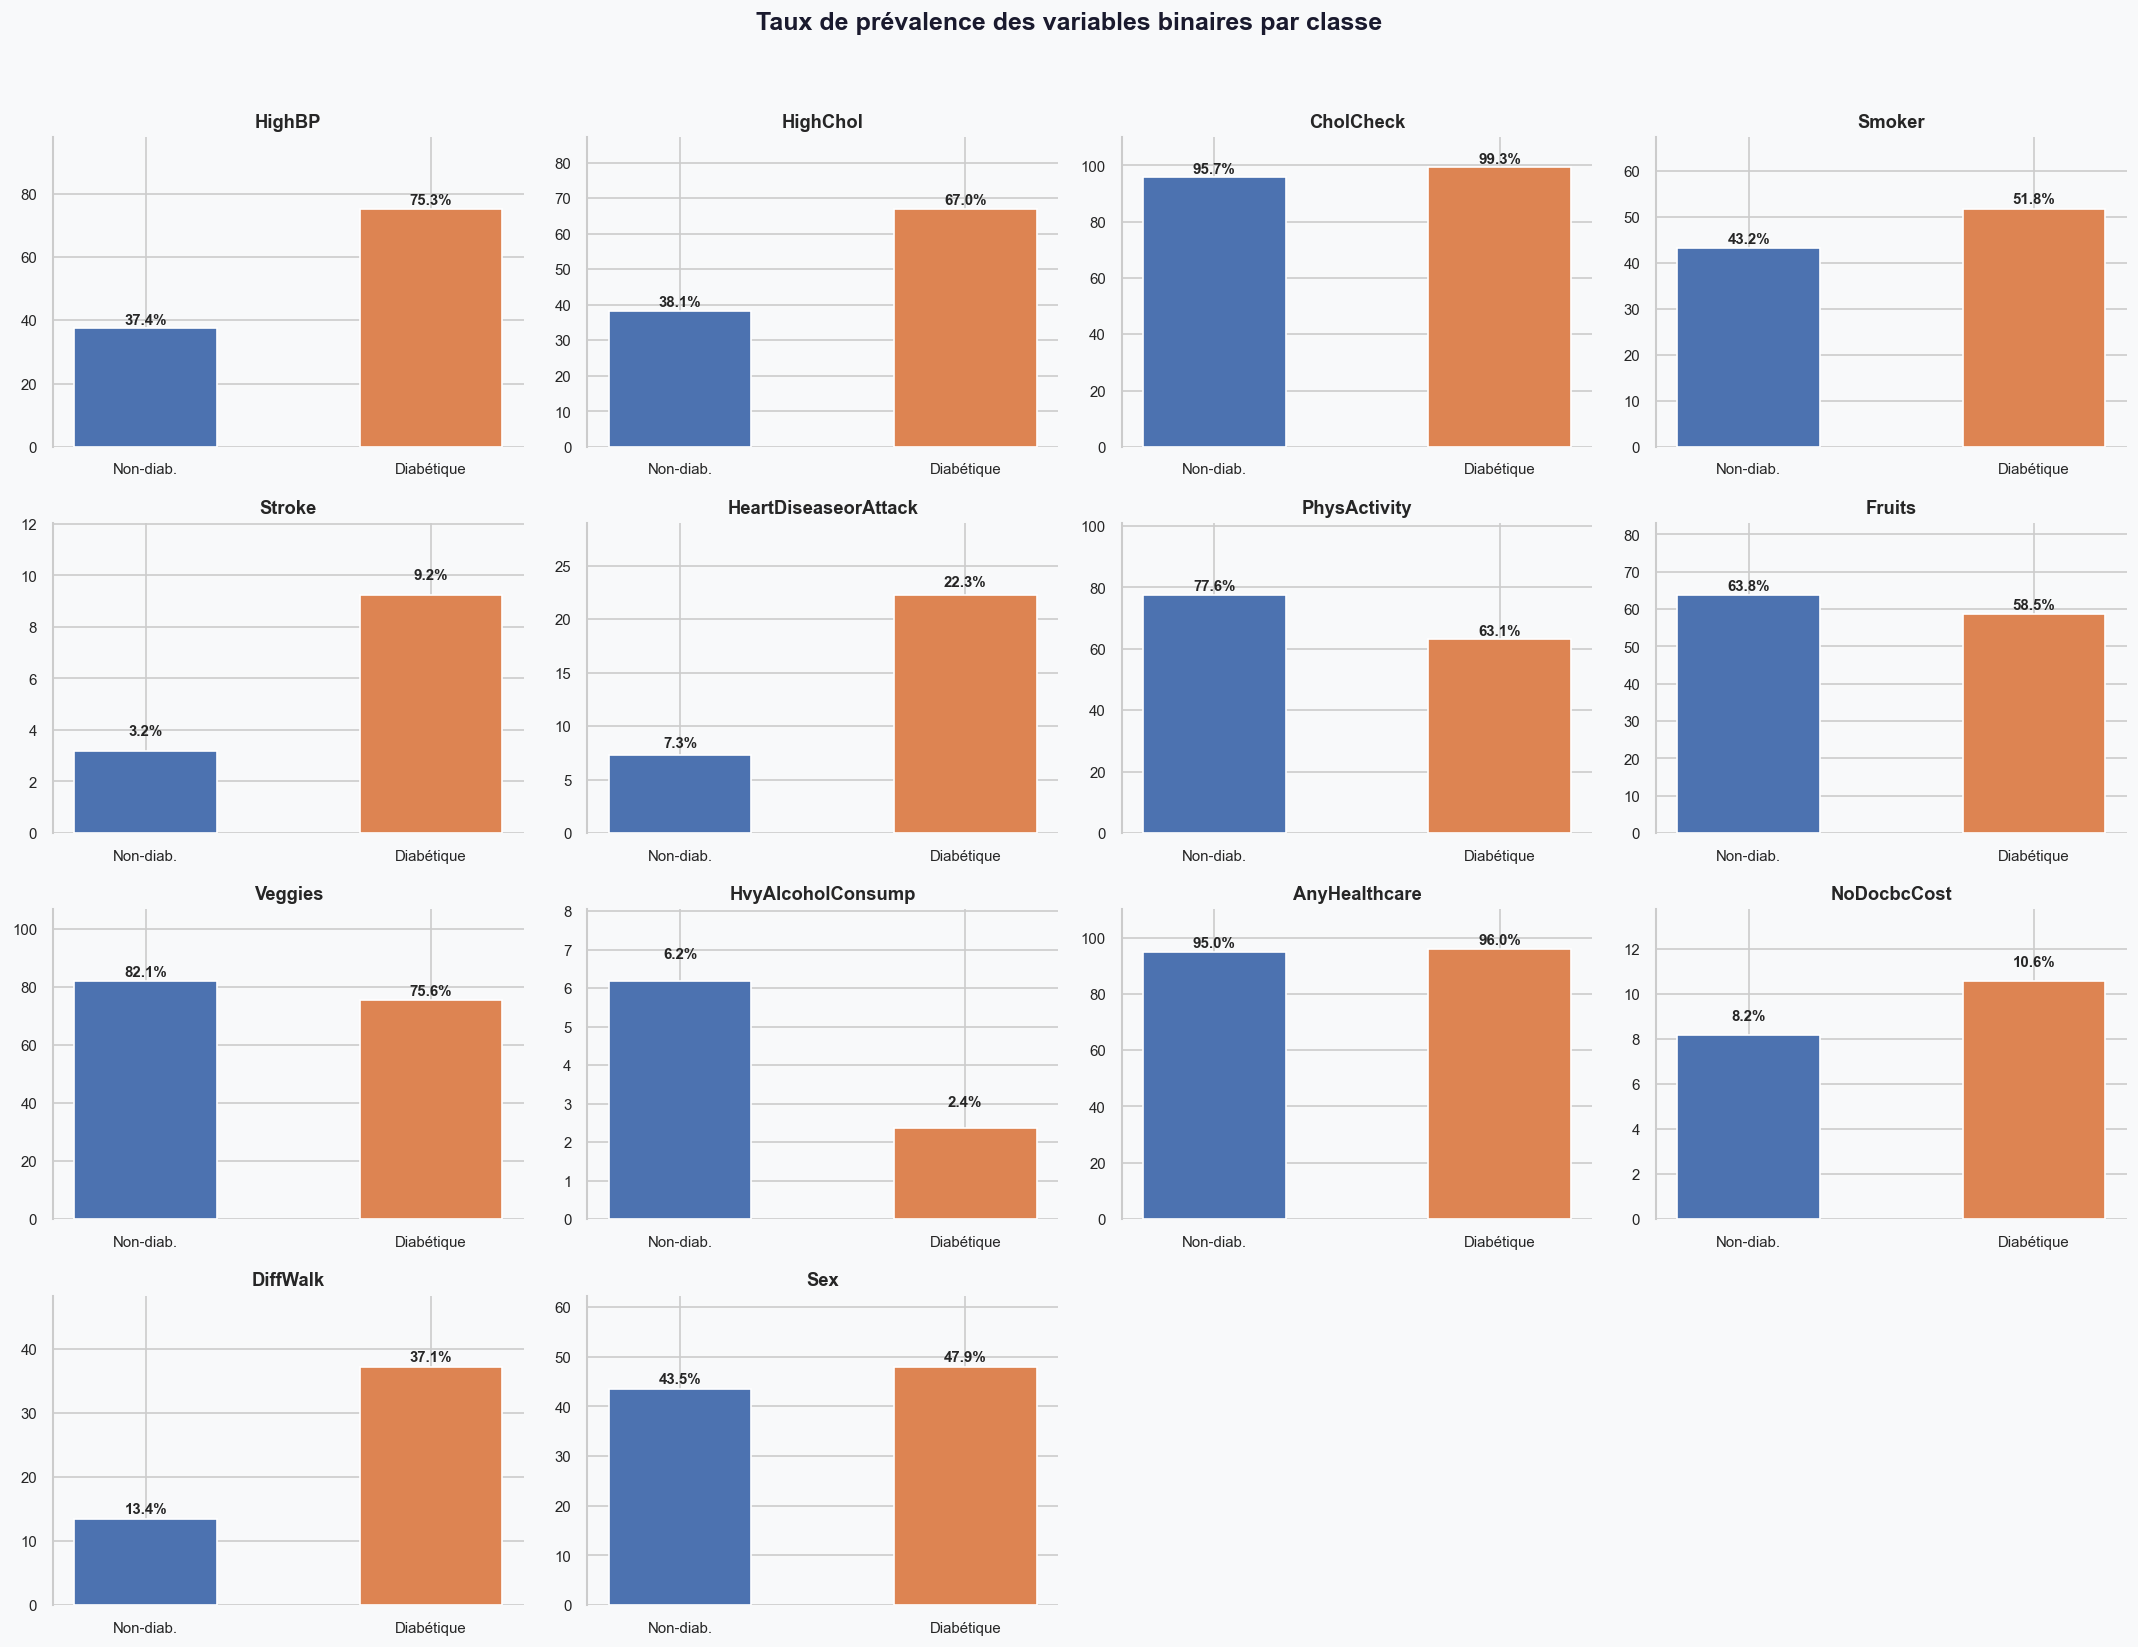

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14), facecolor=BG)
fig.suptitle('Taux de prévalence des variables binaires par classe', fontsize=15, fontweight='bold', color=DARK)
axes = axes.flatten()
for i, feat in enumerate(BINARY_FEATURES):
    ax = axes[i]
    rates = raw_df.groupby(TARGET)[feat].mean() * 100
    bars = ax.bar(['Non-diab.', 'Diabétique'], rates.values, color=PALETTE, width=0.5, edgecolor='white')
    for b, v in zip(bars, rates.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(feat, fontsize=11)
    ax.set_ylim(0, min(rates.max()*1.3, 110))
    ax.tick_params(bottom=False, labelsize=9)
    sns.despine(ax=ax, bottom=True)
for j in range(len(BINARY_FEATURES), len(axes)): axes[j].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


### 5.2 BMI

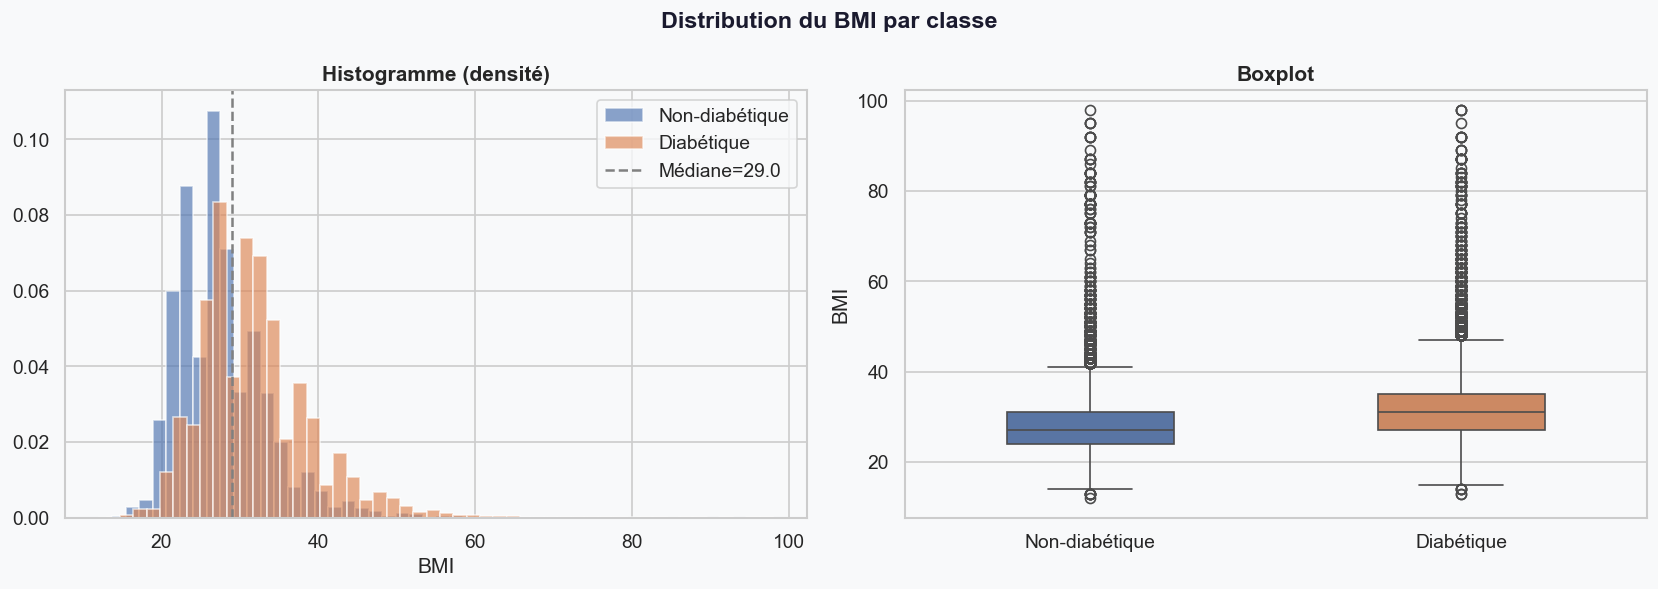

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,,,,,,,,
0.0,35346.0,27.77,6.19,12.0,24.0,27.0,31.0,98.0
1.0,35346.0,31.94,7.36,13.0,27.0,31.0,35.0,98.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Distribution du BMI par classe', fontsize=14, fontweight='bold', color=DARK)
for label, color, name in zip([0,1], PALETTE, ['Non-diabétique','Diabétique']):
    axes[0].hist(raw_df[raw_df[TARGET]==label]['BMI'], bins=50, alpha=0.65,
                 color=color, label=name, density=True)
axes[0].axvline(raw_df['BMI'].median(), color='gray', linestyle='--', linewidth=1.5,
                label=f"Médiane={raw_df['BMI'].median():.1f}")
axes[0].set_title('Histogramme (densité)'); axes[0].set_xlabel('BMI'); axes[0].legend()
df_bmi = raw_df[[TARGET,'BMI']].copy()
df_bmi[TARGET] = df_bmi[TARGET].map({0:'Non-diabétique', 1:'Diabétique'})
sns.boxplot(data=df_bmi, x=TARGET, y='BMI', palette=PALETTE, ax=axes[1], width=0.45)
axes[1].set_title('Boxplot'); axes[1].set_xlabel('')
plt.tight_layout(); plt.show()
raw_df.groupby(TARGET)['BMI'].describe().round(2)


### 5.3 Variables ordinales

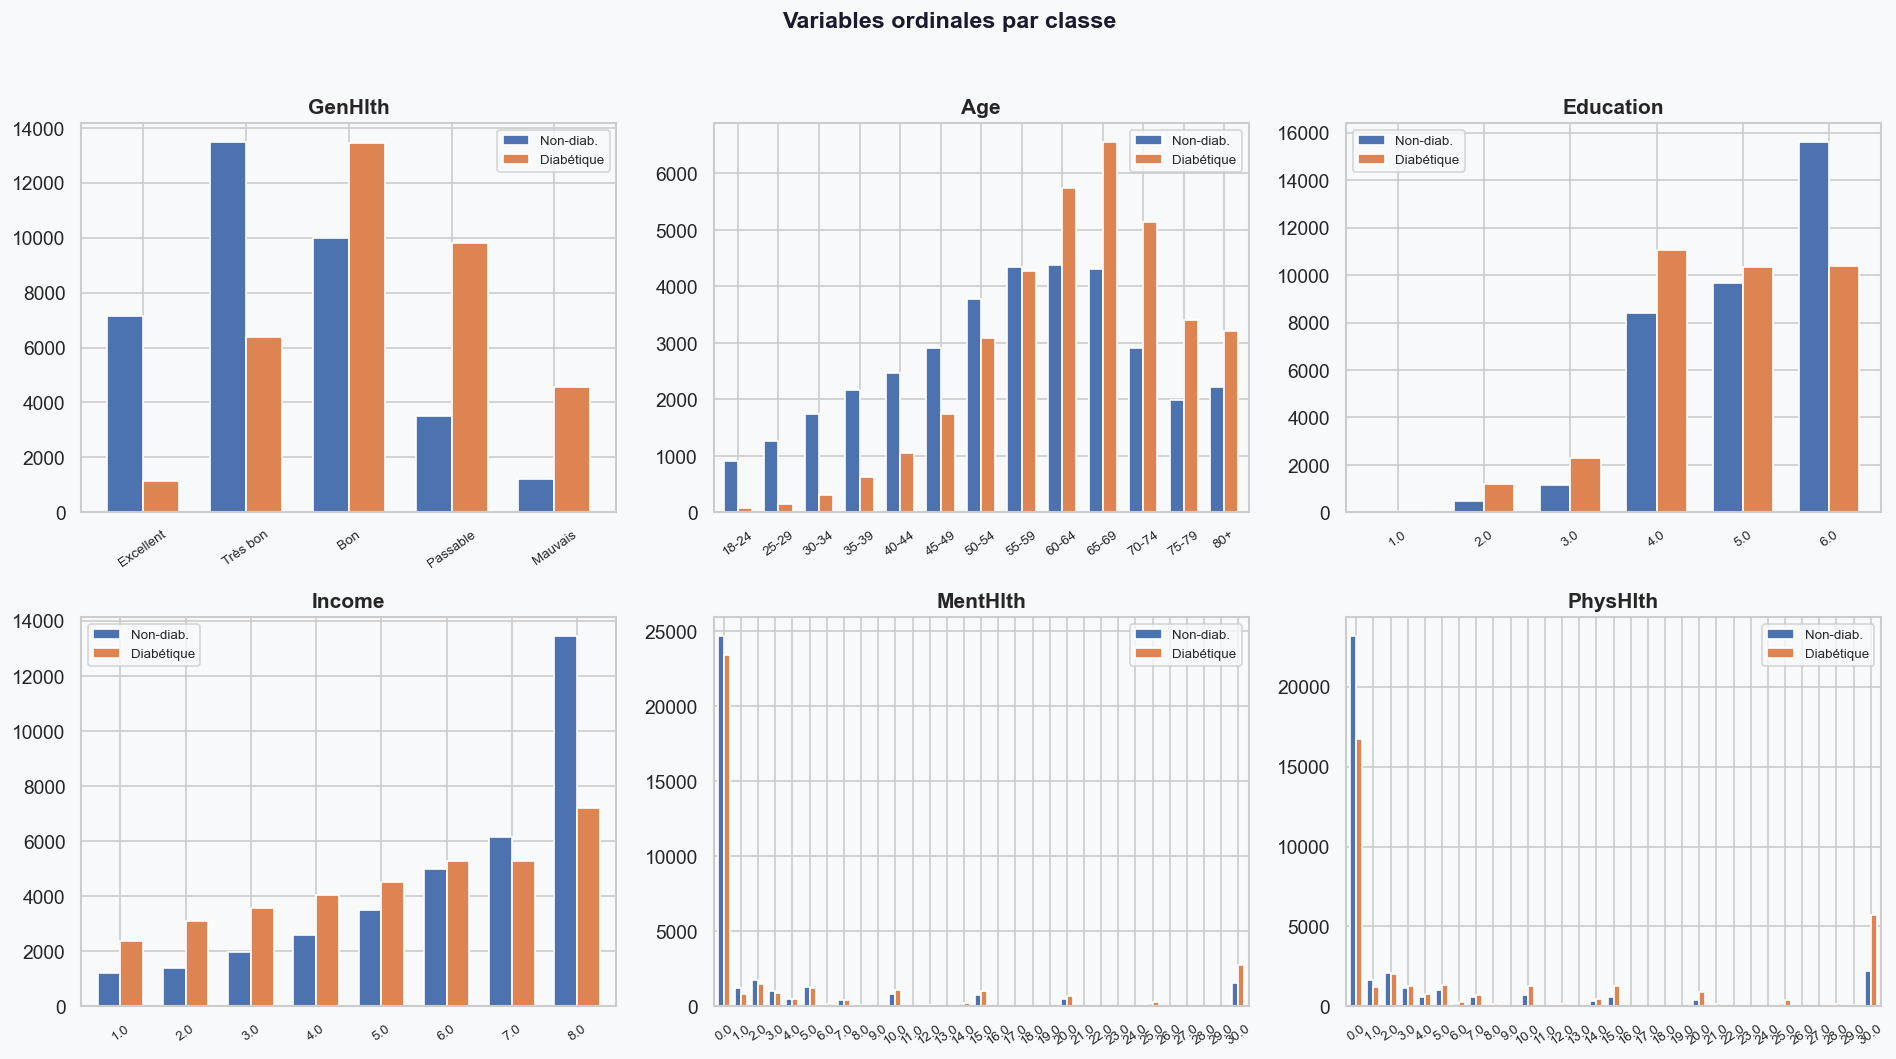

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), facecolor=BG)
fig.suptitle('Variables ordinales par classe', fontsize=14, fontweight='bold', color=DARK)
axes = axes.flatten()
age_labels = {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',6:'45-49',
              7:'50-54',8:'55-59',9:'60-64',10:'65-69',11:'70-74',12:'75-79',13:'80+'}
glabels = {1:'Excellent',2:'Très bon',3:'Bon',4:'Passable',5:'Mauvais'}
for i, feat in enumerate(ORDINAL_FEATURES + ['MentHlth','PhysHlth']):
    ax = axes[i]
    data = raw_df.groupby([TARGET, feat]).size().unstack(0)
    if feat == 'Age':     data.index = [age_labels.get(x, str(x)) for x in data.index]
    if feat == 'GenHlth': data.index = [glabels.get(x, str(x)) for x in data.index]
    data.plot(kind='bar', ax=ax, color=PALETTE, width=0.7, edgecolor='white')
    ax.set_title(feat); ax.set_xlabel('')
    ax.legend(['Non-diab.','Diabétique'], fontsize=8)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


### 5.4 Features engineered

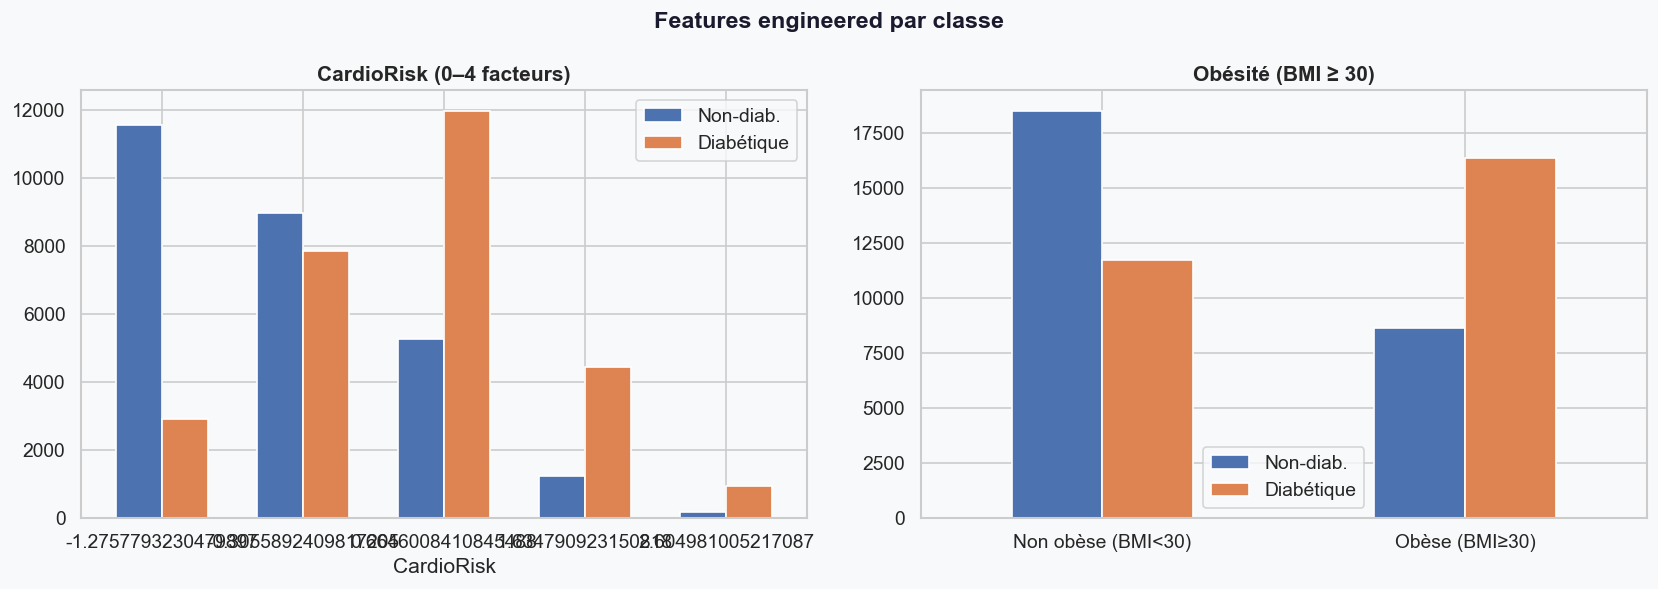

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Features engineered par classe', fontsize=14, fontweight='bold', color=DARK)
cr = train_df.groupby([TARGET, 'CardioRisk']).size().unstack(0)
cr.plot(kind='bar', ax=axes[0], color=PALETTE, width=0.65, edgecolor='white')
axes[0].set_title('CardioRisk (0–4 facteurs)'); axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Non-diab.','Diabétique'])
ob = train_df.groupby([TARGET, 'Obese']).size().unstack(0)
ob.index = ['Non obèse (BMI<30)', 'Obèse (BMI≥30)']
ob.plot(kind='bar', ax=axes[1], color=PALETTE, width=0.5, edgecolor='white')
axes[1].set_title('Obésité (BMI ≥ 30)'); axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Non-diab.','Diabétique'])
plt.tight_layout(); plt.show()


## 6. Heatmap de corrélations <a id='6-correlations'></a>

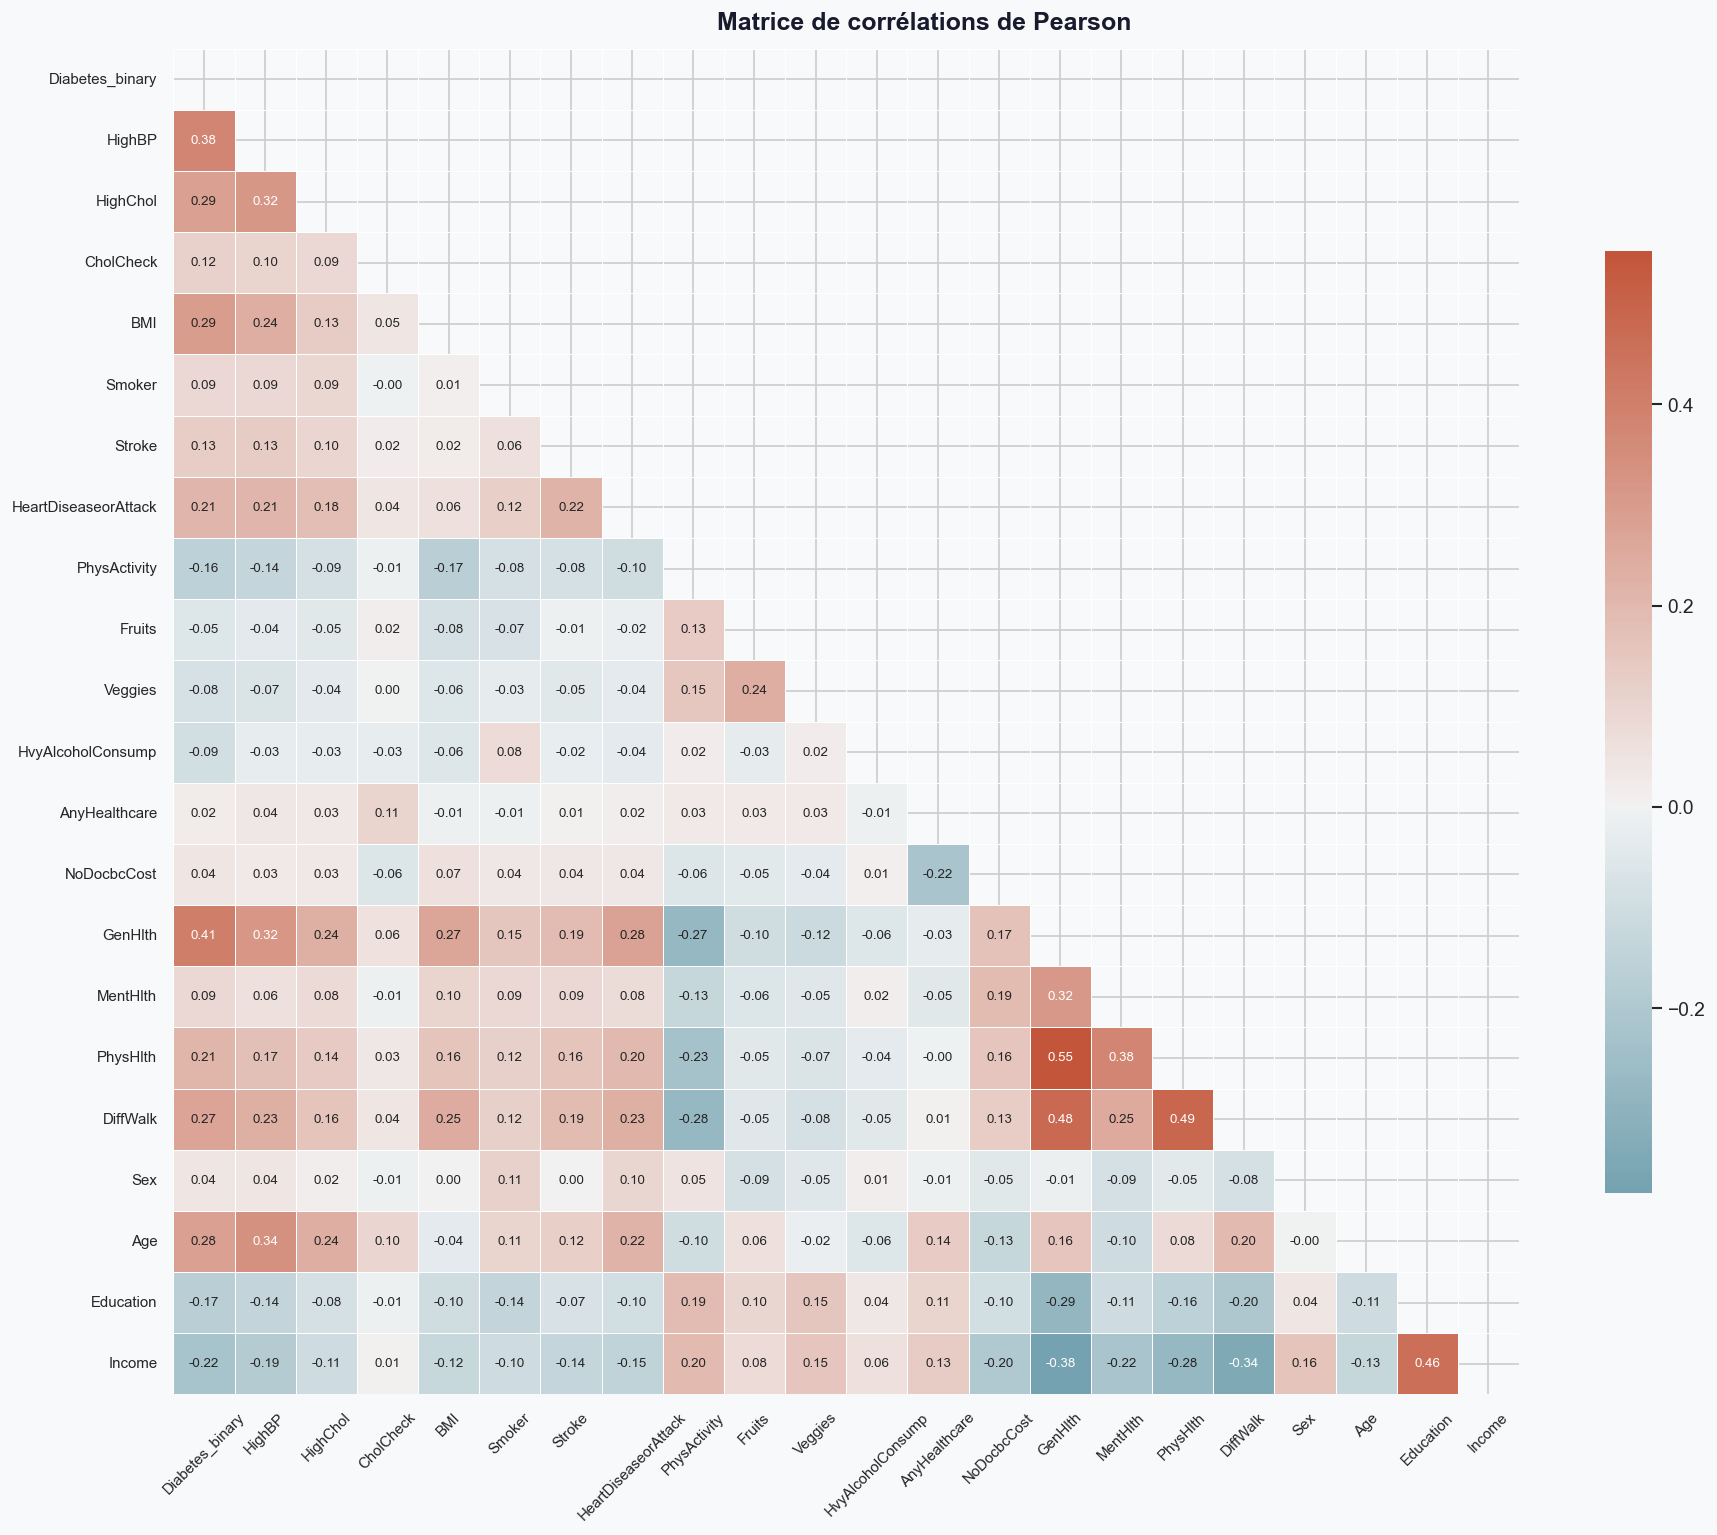

In [12]:
corr = raw_df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 13), facecolor=BG)
fig.suptitle('Matrice de corrélations de Pearson', fontsize=15, fontweight='bold', color=DARK)
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, linecolor='white', square=True, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout(); plt.show()


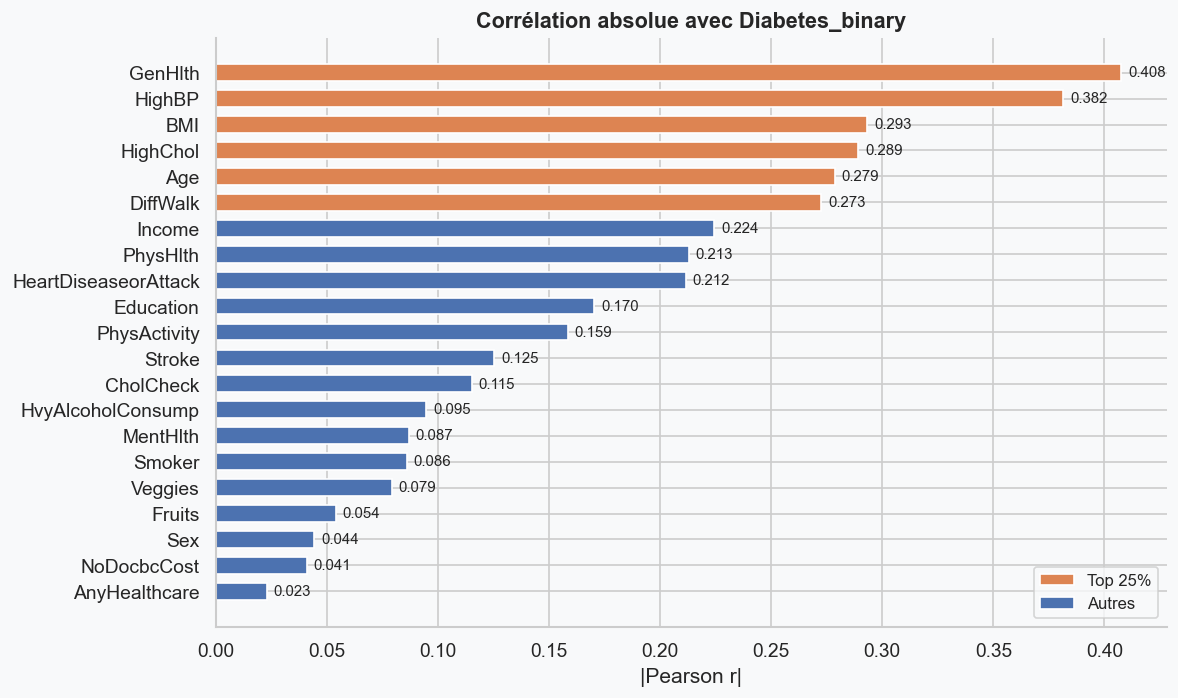

GenHlth     0.407612
HighBP      0.381516
BMI         0.293373
HighChol    0.289213
Age         0.278738


In [13]:
corr_target = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
colors = [ACCENT2 if v >= corr_target.quantile(0.75) else ACCENT for v in corr_target.values]
bars = ax.barh(corr_target.index[::-1], corr_target.values[::-1],
               color=colors[::-1], edgecolor='white', height=0.65)
for b, v in zip(bars, corr_target.values[::-1]):
    ax.text(v+0.003, b.get_y()+b.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
ax.set_title(f'Corrélation absolue avec {TARGET}', fontsize=13, fontweight='bold')
ax.set_xlabel('|Pearson r|')
ax.legend(handles=[Patch(facecolor=ACCENT2, label='Top 25%'), Patch(facecolor=ACCENT, label='Autres')], fontsize=10)
sns.despine(ax=ax); plt.tight_layout(); plt.show()
print(corr_target.head(5).to_string())


## 7. Feature Importance — Random Forest <a id='7-importance'></a>

In [14]:
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
rf = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
print(f'✅ RF entraîné sur {len(X_train):,} obs. · {X_train.shape[1]} features')


✅ RF entraîné sur 55,245 obs. · 25 features


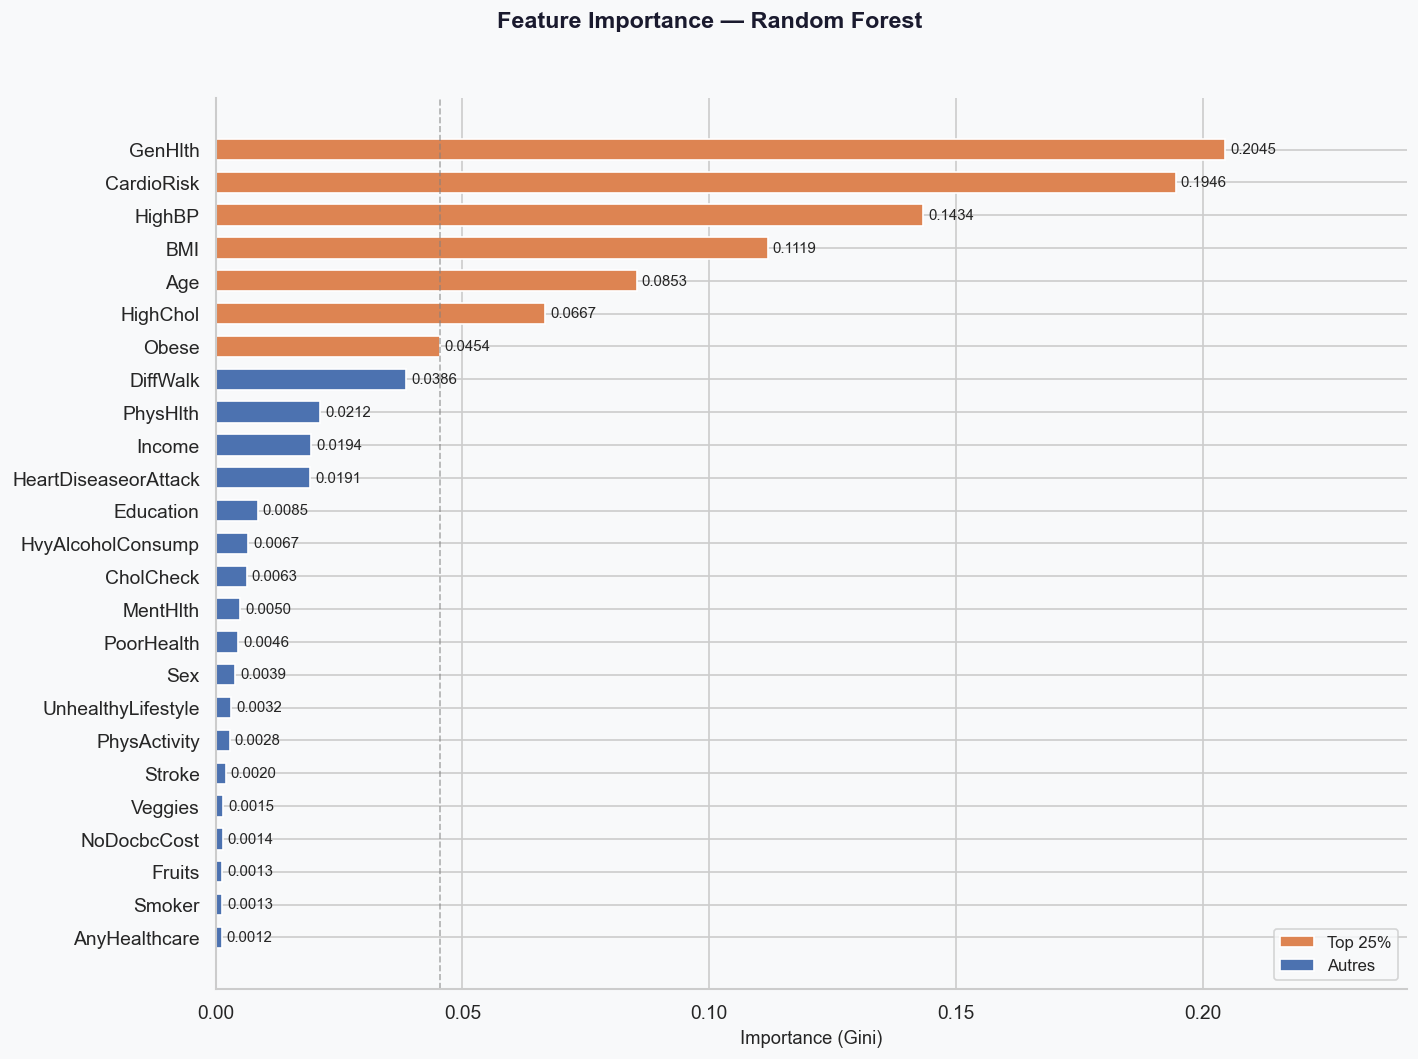

In [15]:
colors_bar = [ACCENT2 if v >= importances.quantile(0.75) else ACCENT for v in importances.values]
fig, ax = plt.subplots(figsize=(12, 9), facecolor=BG)
fig.suptitle('Feature Importance — Random Forest', fontsize=14, fontweight='bold', color=DARK)
bars = ax.barh(importances.index, importances.values, color=colors_bar, edgecolor='white', height=0.65)
for b, v in zip(bars, importances.values):
    ax.text(v+0.001, b.get_y()+b.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
ax.set_xlabel('Importance (Gini)', fontsize=11)
ax.set_xlim(0, importances.max()*1.18)
ax.axvline(importances.quantile(0.75), color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.legend(handles=[Patch(facecolor=ACCENT2, label='Top 25%'), Patch(facecolor=ACCENT, label='Autres')],
          loc='lower right', fontsize=10)
sns.despine(ax=ax); plt.tight_layout(rect=[0,0,1,0.96]); plt.show()


In [16]:
imp_df = importances.sort_values(ascending=False).reset_index()
imp_df.columns = ['Feature','Importance']
imp_df['Importance (%)'] = (imp_df['Importance']*100).round(2)
imp_df.index = range(1, len(imp_df)+1)
imp_df.index.name = 'Rang'
imp_df


,Feature,Importance,Importance (%)
Rang,,,
1,GenHlth,0.204506,20.45
2,CardioRisk,0.194563,19.46
3,HighBP,0.143369,14.34
4,BMI,0.111897,11.19
5,Age,0.085336,8.53
6,HighChol,0.066743,6.67
7,Obese,0.045373,4.54
8,DiffWalk,0.038649,3.86
9,PhysHlth,0.021202,2.12


## 8. Conclusions & prochaines étapes <a id='8-conclusions'></a>

### 📊 Résultats EDA

| # | Observation |
|---|---|
| 1 | **1 635 doublons** supprimés (2.3% du dataset brut) |
| 2 | **Aucune valeur manquante** 
| 3 | **Classes parfaitement équilibrées** (50/50) |
| 4 | **Top features :** `HighBP`, `GenHlth`, `BMI`, `HighChol`, `Age` |
| 5 | **BMI médian** : ~30 (diabétiques) vs ~27 (non-diabétiques) |
| 6 | **4 features engineered** ajoutées : `Obese`, `CardioRisk`, `UnhealthyLifestyle`, `PoorHealth` |

